In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV

from sklearn.metrics import f1_score,accuracy_score,classification_report,recall_score,precision_score,confusion_matrix,RocCurveDisplay


In [3]:
data=pd.read_csv("disease.csv")

In [5]:
data.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
data.dtypes

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

In [8]:
data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
data

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [11]:
data.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [14]:
patients=data.groupby("age")["num"].sum()
patients.head(5)

age
28    0
29    0
30    0
31    1
32    2
Name: num, dtype: int64

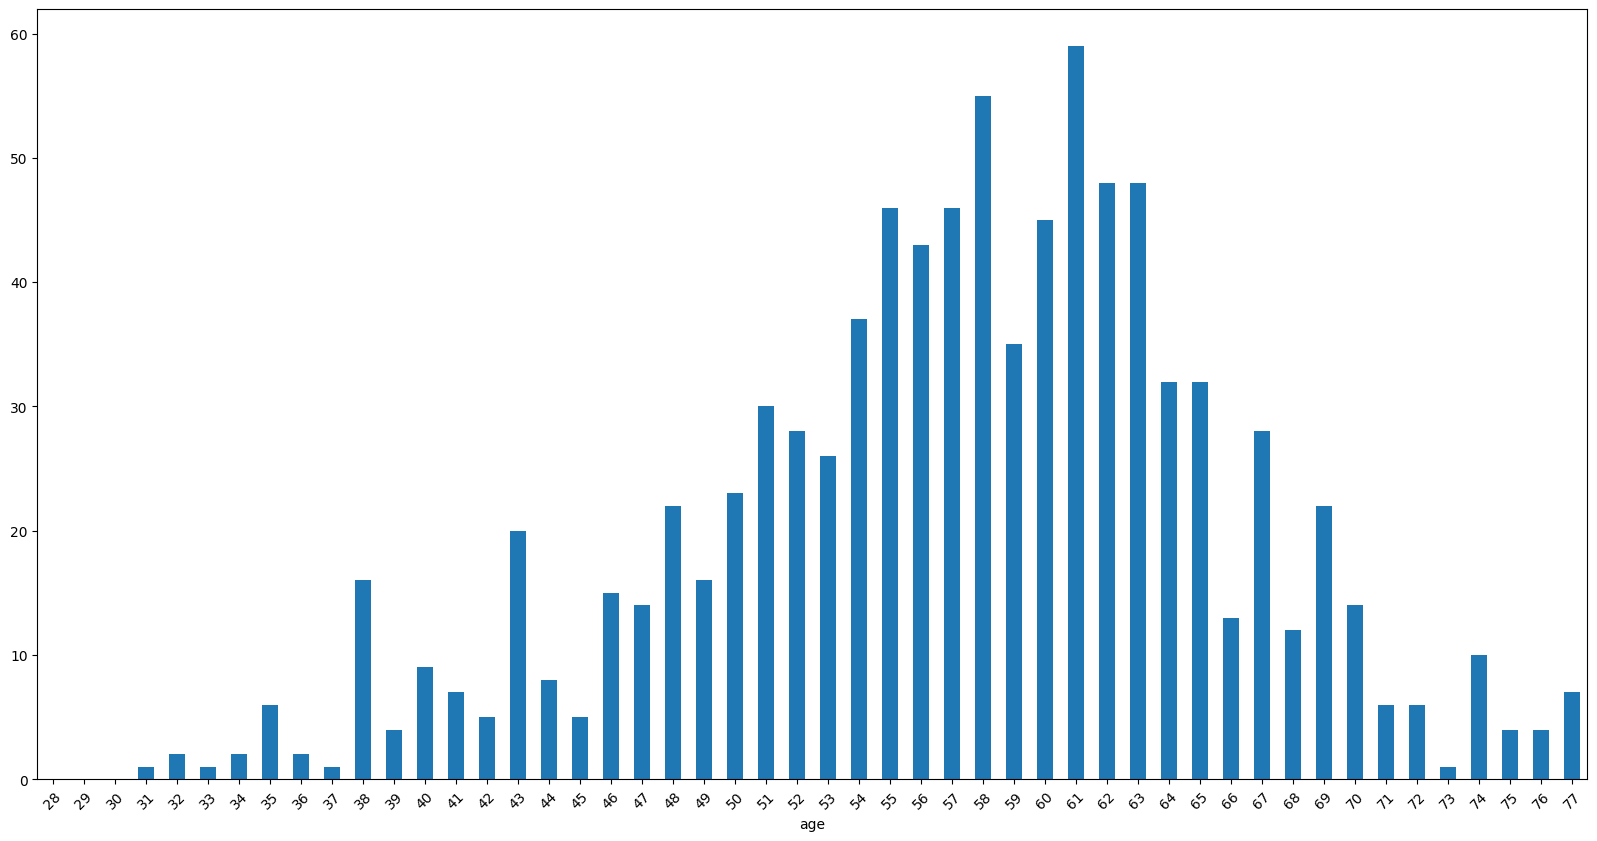

In [25]:
patients.plot(kind="bar",figsize=(20,10))
plt.xticks(rotation=45);

In [27]:
sex_wise=data.groupby("sex")["num"].sum()
sex_wise

sex
Female     82
Male      834
Name: num, dtype: int64

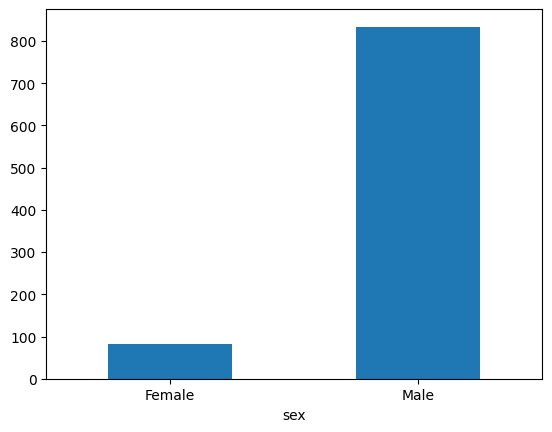

In [35]:
sex_wise.plot(kind="bar")
plt.xticks(rotation=360);

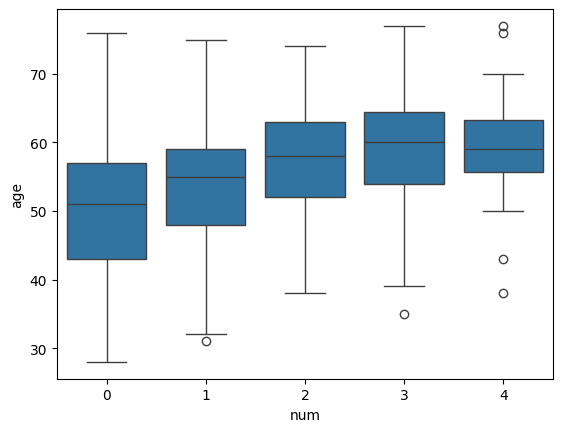

In [36]:
sns.boxplot(x="num",y="age",data=data)
plt.show()

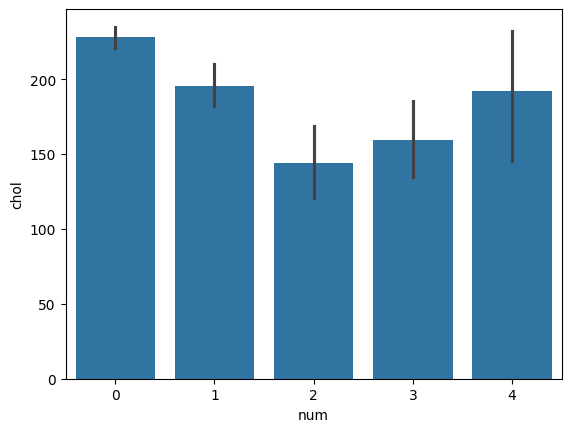

In [39]:
sns.barplot(x="num",y="chol",data=data)
plt.show()

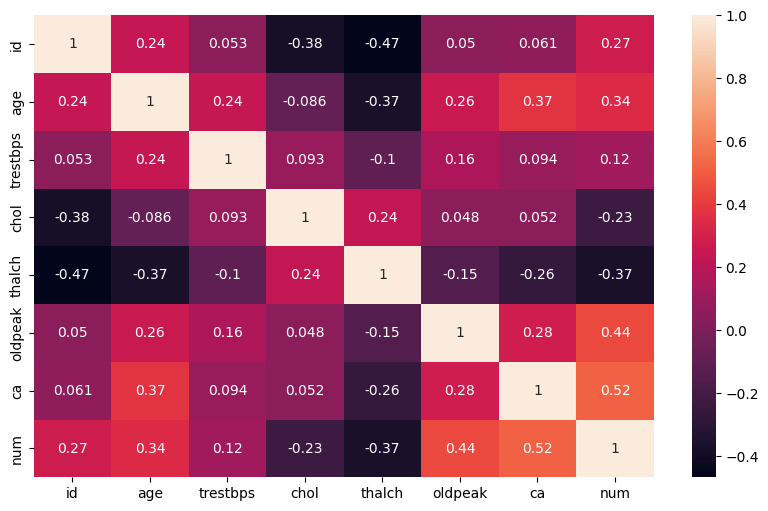

In [40]:
corr=data.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True)
plt.show()

In [41]:
X=data.drop("num",axis=1)
y=data["num"]

In [44]:
categorical_features=["sex","dataset","cp","fbs","restecg","exang","slope","thal"]
numeric_features=["age","trestbps","chol","thalch","oldpeak","ca"]

In [53]:
categorical_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))
])

In [59]:
from sklearn.preprocessing import StandardScaler
numeric_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

In [105]:
preprocessor=ColumnTransformer(
    transformers=[
        ("cat",categorical_transformer,categorical_features),
        ("num",numeric_transformer,numeric_features)
    ]
)

X_processed = preprocessor.fit_transform(X_train)

print(np.isnan(X_processed).sum())

0


In [106]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
from sklearn.tree import DecisionTreeClassifier
models={
    "Logistic Regression ": LogisticRegression(max_iter=1000),
    "Decision Tree ": DecisionTreeClassifier(),
    "Random Forest " : RandomForestClassifier()
}

for name, model in models.items():
    pipe=Pipeline(steps=[
        ("preprocessor",preprocessor),
        ("model",model)
    ])

    pipe.fit(X_train,y_train)

    score=pipe.score(X_test,y_test)

    print(f"{name} : {score*100:.2f}%")



Logistic Regression  : 55.98%
Decision Tree  : 54.89%
Random Forest  : 59.78%


In [87]:
from sklearn.model_selection import GridSearchCV

pipess=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier())
])
param_grid={
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,15,20,None],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4]
}
Grid=GridSearchCV(pipe,param_grid,cv=5,n_jobs=-1)

Grid.fit(X_train,y_train)

print(Grid.best_params_)

{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [89]:
best_model=Grid.best_estimator_

In [90]:
best_model.score(X_test,y_test)

0.532608695652174

In [92]:
y_pred=best_model.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 3,
       1, 3, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 3, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 3, 1, 0, 1, 0, 1, 3, 1, 0, 0, 0, 1, 3, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1])

In [94]:
print(confusion_matrix(y_test,y_pred))

[[69  6  0  0  0]
 [24 29  0  1  0]
 [ 5 16  0  4  0]
 [12 14  0  0  0]
 [ 2  0  0  2  0]]


In [95]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.62      0.92      0.74        75
           1       0.45      0.54      0.49        54
           2       0.00      0.00      0.00        25
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00         4

    accuracy                           0.53       184
   macro avg       0.21      0.29      0.25       184
weighted avg       0.38      0.53      0.44       184



C:\Users\TEXON WARE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TEXON WARE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\TEXON WARE\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [99]:
imp=best_model.named_steps["model"].feature_importances_

feature=pd.Series(imp)
feature.sort_values(ascending=False)

6     0.127051
16    0.083996
27    0.079317
15    0.076313
26    0.075672
23    0.071678
3     0.067862
25    0.065889
4     0.041525
7     0.033769
0     0.032909
1     0.032574
24    0.029038
28    0.023270
21    0.020683
5     0.019715
22    0.017105
2     0.015657
8     0.012643
19    0.012068
13    0.010625
18    0.010322
14    0.009358
12    0.008224
11    0.006295
10    0.004969
20    0.004634
9     0.003935
17    0.002901
dtype: float64

In [103]:
X_train.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     45
chol         25
fbs          80
restecg       1
thalch       42
exang        42
oldpeak      45
slope       238
ca          486
thal        390
dtype: int64

In [108]:
import numpy as np

print(np.isnan(X_final).sum())

NameError: name 'X_final' is not defined